# Preprocess a raw `.h5` into a cleaned `.npz`

This example takes a raw Maxwell recording and runs it through a **preprocessing pipeline that you
define** — you pick which cleaning steps run, in what order, and with what parameters — then saves the
cleaned data as an `.npz` for later burst detection / analysis.

The moving parts:

- **`Config`** (`mxtreme.config`) — reads `mxtreme.toml` to find the *managed data store* (where outputs
  are written and later read back). Raw inputs are pointed at by explicit path.
- **`extract`** (`mxtreme.extract`) — raw `.h5` → per-well data dicts.
- **`clean`** (`mxtreme.clean`) — the menu of composable cleaning steps.
- **`Pipeline`** (`mxtreme.pipeline`) — runs your chosen steps over every well and saves the result.
- **`io`** (`mxtreme.io`) — read/write `.npz`, plus experimental-conditions and registry writers.

> Run this notebook from the `examples/` directory so the relative paths resolve.

In [1]:
from functools import partial
from pathlib import Path

from mxtreme.config import Config
from mxtreme import extract, clean, io
from mxtreme.pipeline import Pipeline

# The managed store (outputs) comes from the TOML — edit examples/mxtreme.toml to point elsewhere.
config = Config.from_toml("mxtreme.toml")
print("managed store root:", config.data_root.resolve())
print("preprocessed dir: ", config.preprocessed_dir.resolve())

managed store root: /home/ephys/Documents/mxtreme-dev/mxtreme-claude/claude_output
preprocessed dir:  /home/ephys/Documents/mxtreme-dev/mxtreme-claude/claude_output/preprocessed


## 1. Extract the raw recording

The newer file format embeds its metadata (Exp ID / Chip ID / Plate date / DIV) inside the `.h5`, so
`extract()` reads it automatically — no manual dict needed.

In [11]:
RAW_ROOT = Path("../../mxtreme-claude/claude_data/raw")   # read-only example data
RAW_H5 = RAW_ROOT / "Fall_BurstTrainer" / "M07140" / "111825_M07140_DIV33_burst_trainer.raw.h5"

data = extract.extract(str(RAW_H5))          # embedded /assay/metadata read automatically
print("wells extracted:", list(data))

w = data[0]
print("exp_id / chip / DIV:", w["exp_id"], w["chip"], w["DIV"])
print("raw spike count:", len(w["data"]))

well 0 : {'left_stim': 0, 'right_stim': 0}
well 1 : {'left_stim': 0, 'right_stim': 0}
well 2 : {'left_stim': 1, 'right_stim': 0}
well 3 : {'left_stim': 0, 'right_stim': 2}
well 4 : {'left_stim': 2, 'right_stim': 1}
well 5 : {'left_stim': 0, 'right_stim': 2}
wells extracted: [0, 1, 2, 3, 4, 5]
exp_id / chip / DIV: burstTrainer M07140 33
raw spike count: 17641682


**Older files** (e.g. `May2025_Wave`) predate the embedded-metadata format, so you supply the
metadata yourself. The pipeline is otherwise identical:

```python
OLD_H5 = RAW_ROOT / "May2025_Wave" / "M07459" / "250512" / "0" / "well0" / "May2025_Wave_well_0.raw.h5"
metadata = {"Exp ID": "May2025_Wave", "Chip ID": "M07459", "Plate date": 250512, "DIV": 0}
data = extract.extract(str(OLD_H5), metadata=metadata, wells=0)
```

## 2. Define **your** pipeline

This is the part you edit. Each entry is a cleaning function from `mxtreme.clean`. Use a bare function
to accept its default parameters, or wrap it with `partial(...)` to override them. Drop steps you don't
want, or reorder them.

Defaults shown below mirror the historical settings (20 µV amplitude cut, 2 ms refractory, no post-stim
window, 10 ms bins).

In [14]:
pipeline = Pipeline([
    clean.normalize_time,                                     # frames -> start at 0
    clean.dac_to_voltage,                                     # DAC units -> volts
    clean.remove_positive_deflections,                        # keep negative spikes
    partial(clean.spike_filter, amp_thresh=2e-5),             # drop < 20 µV  (omit to skip)
    partial(clean.remove_spurious_spikes, refractory_period=0.002),
    clean.remove_spurious_channels,                           # drop unmapped channels
    clean.build_channel_map,                                  # needed before binning
    partial(clean.remove_stim_frames, post_stim_period=0.0),  # drop stim-window spikes
    partial(clean.bin_spikes, bin_size=0.01),                 # 10 ms bins
])

## 3. Run it — transforms every well and saves the cleaned `.npz`

Outputs are written under the managed store from your config (never under the read-only `claude_data`).
The experimental-conditions CSV and registry update are optional extras.

In [15]:
paths = pipeline.run(data, datastore=config.preprocessed_dir)

# Optional side outputs:
io.write_experimental_conditions(data, config.experimental_conditions_dir)
io.register(data, config.registry_path)

paths

Applying amplitude filter with threshold of 20.0 µV...


ValueError: Amplitude threshold is too high.

## 4. Verify — reload the saved file

Check the cleaned data loads back and that `preprocessing_params` records exactly which steps/params ran.

In [5]:
loaded = io.load_preprocessed(paths[0])
print("saved file:        ", paths[0])
print("spike_data shape:  ", loaded["spike_data"].shape)
print("channelmap shape:  ", loaded["channelmap"].shape)
print("spike_bin shape:   ", loaded["spike_bin"].shape)
print("samp_rate:         ", float(loaded["samp_rate"][0]))
print("bin_size (s):      ", float(loaded["bin_size"]))
print("preprocessing_params:", loaded["preprocessing_params"].item())

saved file:         ../../mxtreme-claude/claude_output/preprocessed/m1BurstTrainer/P004722/well0/DIV48_111825_P004722_m1BurstTrainer_well0_exp_data.npz
spike_data shape:   (2089828,)
channelmap shape:   (1016, 5)
spike_bin shape:    (1016, 360504)
samp_rate:          20000.0
bin_size (s):       0.01
preprocessing_params: {'amp_thresh': 2e-05, 'refractory_period': 0.002, 'post_stim_period': 0.0, 'bin_size': 0.01}


## 5. Visualize the data

Three basic, analysis-free views of the cleaned recording, from `mxtreme.visualizations`:
- **ASDR** — array-wide spike detection rate over time (mean binned activity across channels).
- **Raster** — binned spikes, channels × time.
- **MEA map** — spatial layout of the electrodes (⚡ marks stimulation electrodes).

We use the reloaded npz from the previous cell. The ASDR + raster share an x-axis over a short window of
bins so the structure is visible.

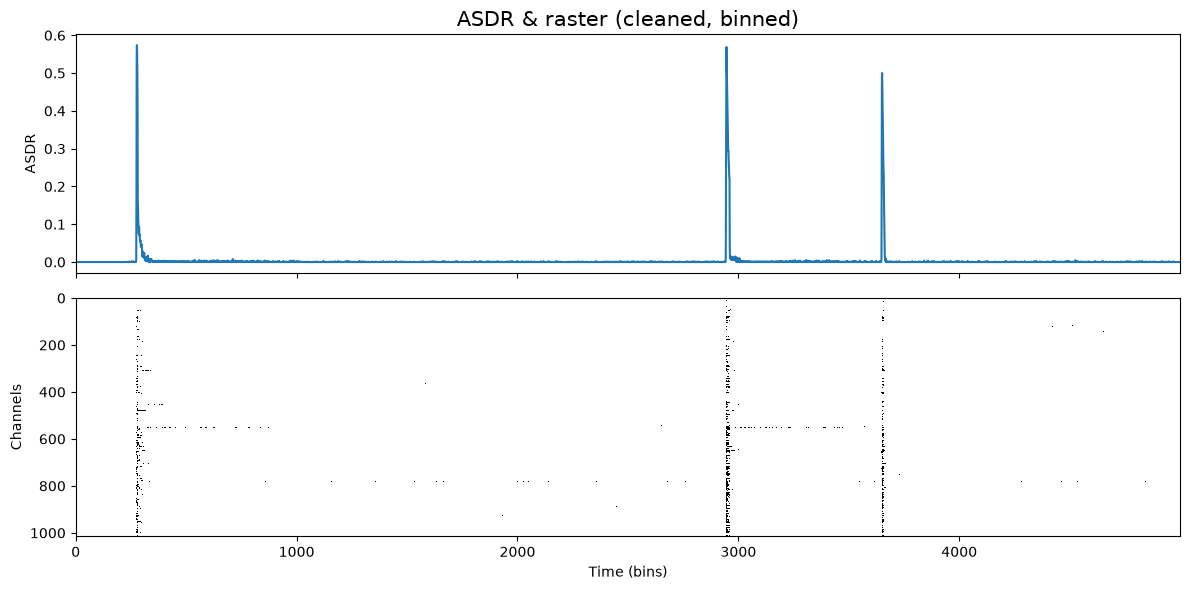

In [8]:
from mxtreme import visualizations as viz
import matplotlib.pyplot as plt

sb = loaded["spike_bin"]
win = (0, min(5000, sb.shape[1]))          # window of bins to display (10 ms bins)
sb_win = sb[:, win[0]:win[1]]

fig, (ax_asdr, ax_rast) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
viz.plot_asdr(sb_win, ax=ax_asdr, title="ASDR & raster (cleaned, binned)")
viz.raster(sb_win, ax=ax_rast)
ax_asdr.set_xlabel("")
plt.tight_layout()
plt.show()

In [10]:
loaded["stim_elecs"]

array([0])

Left: 492, Right: 516


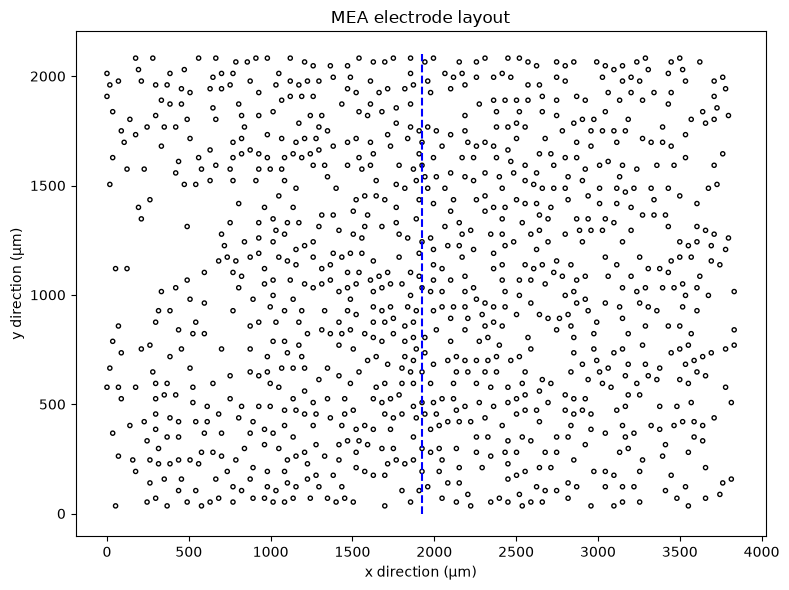

In [9]:
# Spatial map of the electrodes on the MEA
stim = loaded["stim_elecs"]
stim = stim.item() if getattr(stim, "ndim", 1) == 0 else stim   # unwrap 0-d object array (may be None)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
viz.MEA(ax, loaded["channelmap"], stim, title="MEA electrode layout")
plt.tight_layout()
plt.show()